In [26]:
import pyranges as pr
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.graph_objects as go

import matplotlib.patches as patches

In [2]:
%%time 
# === Load and filter GTF ===
gtf_file = "/nfs/turbo/umms-indikar/shared/projects/reference_genome/prebuilt/refdata-gex-GRCh38-2024-A/genes/genes.gtf"
gtf = pr.read_gtf(gtf_file)
gtf = gtf.df

gtf.head()

CPU times: user 53.2 s, sys: 5.46 s, total: 58.7 s
Wall time: 58.8 s


,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_version,...,transcript_name,transcript_support_level,havana_transcript,exon_number,exon_id,exon_version,hgnc_id,havana_gene,protein_id,ccdsid
0,GL000009.2,ENSEMBL,gene,56139,58376,.,-,.,ENSG00000278704,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GL000009.2,ENSEMBL,transcript,56139,58376,.,-,.,ENSG00000278704,1,...,ENST00000618686,NA,NaN,NaN,NaN,NaN,NaN,NaN,ENSP00000484918.1,NaN
2,GL000009.2,ENSEMBL,exon,56139,58376,.,-,.,ENSG00000278704,1,...,ENST00000618686,NA,NaN,1,ENSE00003753029,1,NaN,NaN,ENSP00000484918.1,NaN
3,GL000009.2,ENSEMBL,CDS,58083,58308,.,-,0,ENSG00000278704,1,...,ENST00000618686,NA,NaN,1,ENSE00003753029,1,NaN,NaN,ENSP00000484918.1,NaN
4,GL000009.2,ENSEMBL,start_codon,58305,58308,.,-,0,ENSG00000278704,1,...,ENST00000618686,NA,NaN,1,ENSE00003753029,1,NaN,NaN,ENSP00000484918.1,NaN


In [97]:
%%time

query = [
    'TEAD4-202',
    'TEAD4-207',
]

columns = [
    'transcript_name',
    'Chromosome',
    'Start', 
    'End',
    'exon_id',
    'exon_version',
]

df = gtf[gtf['transcript_name'].isin(query)].copy()
df = df[df['Feature'] == 'exon']
df = df[columns]
print(f"{df.shape=}")

# Sort by transcript and exon number
df = df.sort_values(["Start"])

print(df.head().to_string(index=False))

df.shape=(19, 6)
transcript_name Chromosome   Start     End         exon_id exon_version
      TEAD4-202      chr12 2959396 2959481 ENSE00001796160            3
      TEAD4-207      chr12 2959795 2960040 ENSE00001527372            1
      TEAD4-202      chr12 2959947 2960040 ENSE00001369261            1
      TEAD4-202      chr12 2994737 2994992 ENSE00002224630            1
      TEAD4-207      chr12 2994737 2994992 ENSE00002224630            1
CPU times: user 233 ms, sys: 811 μs, total: 233 ms
Wall time: 233 ms


In [104]:
gap = 10

# Create PyRanges object
gr = pr.PyRanges(df)

# 1. Merge all overlapping intervals across transcripts
merged = gr.merge()

# 2. Create collapsed coordinates for merged blocks
merged_df = merged.df.sort_values("Start").reset_index(drop=True)

# Add gap between blocks
merged_df["Length"] = merged_df["End"] - merged_df["Start"]
merged_df["collapsed_start"] = merged_df["Length"].shift(fill_value=0).cumsum() + gap * merged_df.index
merged_df["collapsed_end"] = merged_df["collapsed_start"] + merged_df["Length"]

def map_exon(row):
    hit = merged_df[(merged_df["Start"] <= row["Start"]) & (merged_df["End"] >= row["End"])].iloc[0]
    offset_start = row["Start"] - hit["Start"]
    return pd.Series({
        "collapsed_start": hit["collapsed_start"] + offset_start,
        "collapsed_end": hit["collapsed_start"] + offset_start + (row["End"] - row["Start"])
    })

df[["collapsed_start", "collapsed_end"]] = df.apply(map_exon, axis=1)

print(df)

        transcript_name Chromosome    Start      End          exon_id  \
1945619       TEAD4-202      chr12  2959396  2959481  ENSE00001796160   
1945668       TEAD4-207      chr12  2959795  2960040  ENSE00001527372   
1945620       TEAD4-202      chr12  2959947  2960040  ENSE00001369261   
1945621       TEAD4-202      chr12  2994737  2994992  ENSE00002224630   
1945669       TEAD4-207      chr12  2994737  2994992  ENSE00002224630   
1945672       TEAD4-207      chr12  3011003  3011068  ENSE00003589946   
1945624       TEAD4-202      chr12  3011003  3011068  ENSE00003589946   
1945626       TEAD4-202      chr12  3012169  3012232  ENSE00003653885   
1945674       TEAD4-207      chr12  3012169  3012232  ENSE00003653885   
1945628       TEAD4-202      chr12  3017397  3017526  ENSE00003494634   
1945676       TEAD4-207      chr12  3017397  3017526  ENSE00003494634   
1945630       TEAD4-202      chr12  3018544  3018588  ENSE00003785144   
1945678       TEAD4-207      chr12  3018544  301858

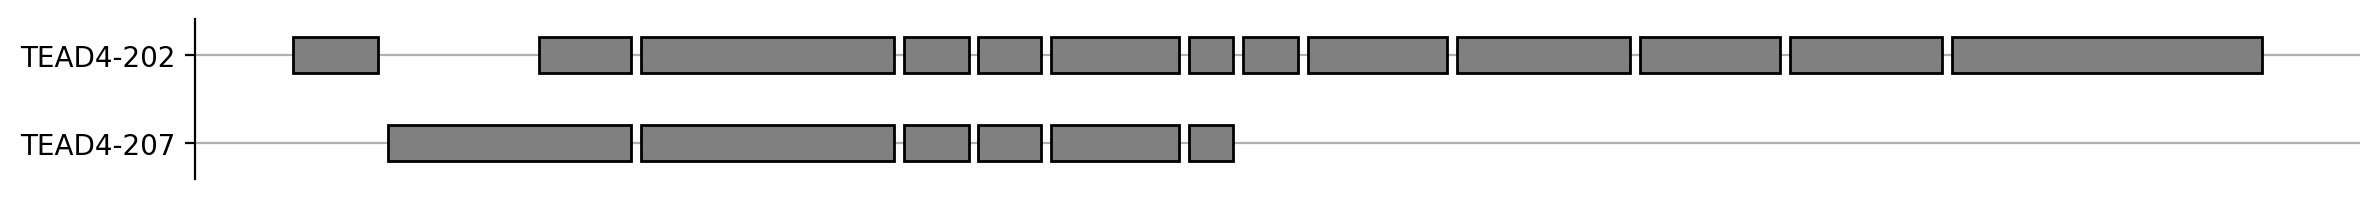

In [114]:
# Plotting
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 12, 1.1

fig, ax = plt.subplots()
exon_height = 0.4
transcripts = df['transcript_name'].unique()

for i, transcript in enumerate(transcripts):
    tdf = df[df['transcript_name'] == transcript]
    y = i
    for _, row in tdf.iterrows():
        rect = patches.Rectangle(
            (row['collapsed_start'], y - exon_height / 2),
            row['collapsed_end'] - row['collapsed_start'],
            exon_height,
            linewidth=1,
            edgecolor='black',
            facecolor='grey',
            zorder=10,
        )
        ax.add_patch(rect)

    # break


# Format
ax.set_yticks(range(len(transcripts)))
ax.set_yticklabels(transcripts)
ax.invert_yaxis()

ax.set_xticks([])
ax.set_xlabel('')
ax.set_facecolor('none')

plt.grid(axis='y', zorder=0)
plt.margins(y=0.15, x=0.05)
sns.despine(bottom=True)
plt.tight_layout()
fig = plt.gcf()
fig.set_facecolor('none')
plt.show()


In [ ]:
break